In [122]:
## automatically reload any modules read below that might have changed (e.g. plots)
%reload_ext autoreload
%autoreload 2

In [123]:
# importing plotting and locus tools: 
import neoom as nf
import NEOMOD3 as nm3  

In [124]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from urllib.request import urlopen
from io import StringIO
import numpy as np
import astropy.units as u
from astropy.time import Time
from numpy import sin, cos
from astropy.coordinates import EarthLocation, get_body_barycentric_posvel, solar_system_ephemeris 
from astropy.coordinates import SkyCoord, get_sun, GCRS, GeocentricTrueEcliptic
import pyarrow as pa
import adam_core.coordinates
from adam_core.time import Timestamp
from adam_core.coordinates import CartesianCoordinates, Origin
from adam_core.constants import KM_P_AU, S_P_DAY
from adam_core.orbits import Orbits
from adam_core.utils import get_perturber_state
from adam_core.coordinates.origin import OriginCodes
from scipy.interpolate import RegularGridInterpolator

import neoonlyS3M as neo3m
import trojans as tjn
import tnos as tn
#importing the neomod3.py file for the 4D array
import NEOMOD3 as nm3

In [24]:
df, array4D, H_center, a_center, e_center, i_center = nm3.getNEOMOD3orbits()

In [25]:
neo_s3m = neo3m.define_s3m()

['S0.s3m']
The final df is done.


In [26]:
neo_s3m,array4D, H_center, a_center, e_center, i_center= neo3m.s3m_array(neo_s3m)

In [27]:
obstime_str="2025-09-23T00:00:00"
#ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day = 186.35, -5.0, 46.27, -19.0
ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day = 80.0, 20.0, 0.12, 0.22 
# add mag here
mag = 20.0
# anti-Sun at Sep 23 = equinox so RA = 0, Dec = 0
ra0_deg, dec0_deg = 0.0, 0.0


In [28]:

l_hat, v_hat = nf.compute_unit_vectors(ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day)
obstime, rE, vE, r_obs = nf.get_earth_and_observer(obstime_str) 
neo_score, a, e, i = nf.compute_neomod3_weight(0.2, 3.0, l_hat, v_hat, obstime, rE, vE, r_obs, array4D, H_center, a_center, e_center, i_center)




print("neo_score:", neo_score)
print("a:", a)
print("e:", e)
print("i:", i)

neo_score: 1.0
a: 1.4547289094311036
e: 0.31736085318504975
i: 2.1368116120813023


In [29]:
def comp_sum1():
    
    N_rate = 31           #2 mins 30 sec, for 31 = 4 mins 20 sec so around 50 mins for 101 --> 1 min 40 s for 31
    vlam_min, vlam_max = -0.6, 0.6
    vbet_min, vbet_max = -0.6, 0.6

    vlam_vals  = np.linspace(vlam_min, vlam_max, N_rate)
    vbet_vals = np.linspace(vbet_min, vbet_max, N_rate)
    vlam_deg_day = 0.12
    vbeta_deg_day = 0.22
    

    
    
    K = np.zeros((len(vlam_vals), len(vbet_vals)), dtype=float)
    
    for i,vlam in enumerate(vlam_vals):
        for j,vbet in enumerate(vbet_vals):
            dra, ddec = nf.ecliptic_rates_to_radec_rates(ra0_deg, dec0_deg, vlam, vbet)
            w_int = nf.weight_marginalized_over_d_and_ddot(array4D=array4D, H_center=H_center, a_center=a_center, e_center=e_center, i_center=i_center,
                                                           ra_deg=ra0_deg, dec_deg=dec0_deg, dra_deg_per_day=dra, ddec_deg_per_day=ddec,obstime_str=obstime_str
                                                        )
            

            K[j, i] = w_int
            #print(w_int, dra, ddec)
        #break
    extent = [vlam_vals[0], vlam_vals[-1], vbet_vals[0], vbet_vals[-1]]
    return K, extent

K, extent= comp_sum1()



/tmp/ipykernel_3169730/1045258599.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  my_viridis = cm.get_cmap("viridis", 1024).with_extremes(under="white")


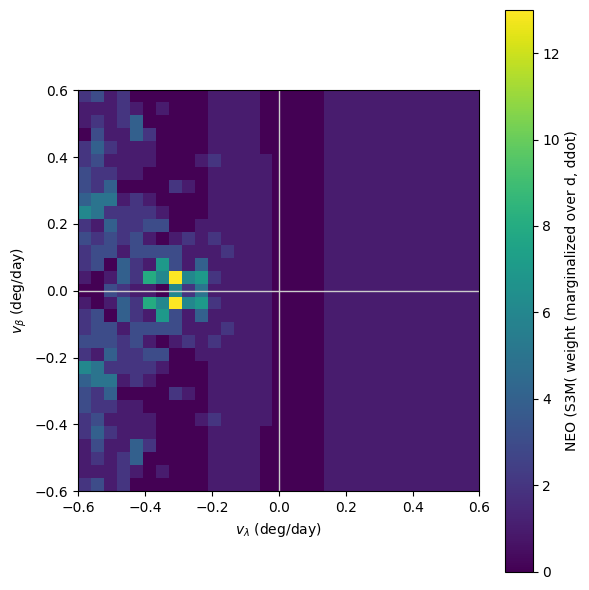

In [31]:
# VERSION WITH FLIPPED DRA VLAMBDA
from matplotlib import cm
plt.figure(figsize=(6.0, 6.0))
 
my_viridis = cm.get_cmap("viridis", 1024).with_extremes(under="white")
im = plt.imshow(K, origin="lower", extent=extent, cmap=my_viridis, aspect="equal")


plt.colorbar(label="NEO (S3M( weight (marginalized over d, ddot)")

plt.axhline(0, color="0.8", lw=1)
plt.axvline(0, color="0.8", lw=1)
plt.xlabel(r"$v_\lambda$ (deg/day)")
plt.ylabel(r"$v_\beta$ (deg/day)")
plt.tight_layout()
plt.show()



In [43]:
# setting value for phi = 0, beta = 0 
phi_deg = 0.0 # on the opposition
beta_deg = 0.0 # on the ecliptic


In [44]:
vE_deg_per_day = 0.986  # earth's orbital speed

def prediction_vlam_vbet(R_au, i_deg, phi_deg, beta_deg=0.0):
    # convert angles to radians
    i = np.deg2rad(i_deg)
    phi = np.deg2rad(phi_deg)
    beta = np.deg2rad(beta_deg)
    
    # from eqn A7 to A8
    theta = phi - np.arcsin(np.sin(phi) / R_au)
    Delta = np.sqrt(R_au**2 + 1.0 - 2.0 * R_au * np.cos(theta))
    
    # heliocentric velocity components 
    v_factor = vE_deg_per_day / np.sqrt(R_au)
    vx = v_factor * np.cos(i) * np.sin(theta)
    vy = v_factor * np.cos(i) * np.cos(theta)
    vz = v_factor * np.sin(i)
    
    # ecliptic rates
    vlam =  (np.sin(phi) * vx + np.cos(phi) * (vy - vE_deg_per_day)) / Delta
    
    vbet = (-np.sin(beta) * np.cos(phi) * vx
            + np.sin(beta) * np.sin(phi) * (vy - vE_deg_per_day)
            + np.cos(beta) * vz) / Delta
    
    return vlam, vbet


In [45]:
i_list = np.arange(-10.0, 15.0, 5.0)  # -10, -5, 0, 5, 10
R_vals = np.linspace(1.5, 4.5, 800)  # AU 

i_lines = []  # [vlam_arr, vbet_arr, i_deg]

for i_deg in i_list:
    vlam_arr = []
    vbet_arr = []
    for R in R_vals:
        vlam, vbet = prediction_vlam_vbet(R, i_deg, phi_deg, beta_deg)
        vlam_arr.append(vlam)
        vbet_arr.append(vbet)
    i_lines.append((np.array(vlam_arr), np.array(vbet_arr), i_deg))


In [46]:
R_list = [2.0, 2.5, 3.0, 3.5]
i_pos = i_center[(i_center >= 0.0) & (i_center <= 40.0)]  # same i-range as neomod3
i_vals_for_R = np.concatenate((-i_pos[::-1], i_pos))
R_lines = []  # [vlam_arr, vbet_arr, R]
for R in R_list:
    vlam_arr = []
    vbet_arr = []
    for i_deg in i_vals_for_R:
        vlam, vbet = prediction_vlam_vbet(R, i_deg, phi_deg, beta_deg)
        vlam_arr.append(vlam)
        vbet_arr.append(vbet)
    R_lines.append((np.array(vlam_arr), np.array(vbet_arr), R))


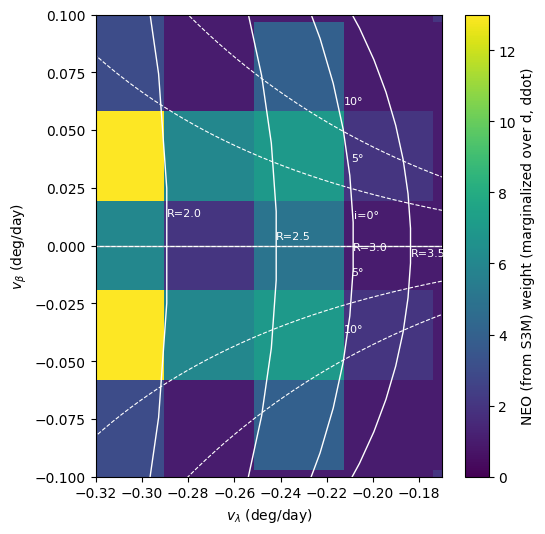

In [47]:
plt.figure(figsize=(6.0, 6.0))
im = plt.imshow(K, origin="lower", extent=extent, cmap="viridis", aspect="equal")
plt.colorbar(label="NEO (from S3M) weight (marginalized over d, ddot)")
plt.axhline(0, color="0.8", lw=1)
plt.axvline(0, color="0.8", lw=1)
plt.xlabel(r"$v_\lambda$ (deg/day)")
plt.ylabel(r"$v_\beta$ (deg/day)")
plt.xlim(-0.32, -0.17)
plt.ylim(-0.1, 0.1)

# solid lines for R
for vlam_arr, vbet_arr, R in R_lines:
    plt.plot(vlam_arr, vbet_arr, color="white", lw=1.0)
    idx = len(vlam_arr) // 2
    plt.text(vlam_arr[idx], vbet_arr[idx] - 0.012,  # a bit below the line
             f"R={R:.1f}", color="white", fontsize=8)

# dashed lines for i
for vlam_arr, vbet_arr, i_deg in i_lines:
    plt.plot(vlam_arr, vbet_arr, color="white", lw=0.8, ls="--")
    idx = len(vlam_arr) // 2
    plt.text(vlam_arr[idx], vbet_arr[idx] + 0.012,
             f"{abs(i_deg):.0f}°" if i_deg != 0 else "i=0°",
             color="white", fontsize=8)

### with only trojans from S3M

In [55]:
trojans_s3m = tjn.define_s3m()

['St5.s3m']
The final df is done.


In [76]:
tjn_s3m,array4D_tjn, H_center_tjn, a_center_tjn, e_center_tjn, i_center_tjn = tjn.s3m_array(trojans_s3m)

In [137]:
tjn_s3m

,OID,FORMAT,q,e,i,node,argperi,t_p,H,t_0,INDEX,N_PAR,MOID,COMPCODE,a
0,St500000a,COM,4.91636,0.05966,7.6084,313.711,150.14863,47268.27529,5.63,54800.0,1,6,-1,Python,5.228279
1,St500001a,COM,4.96652,0.06370,10.4414,100.539,243.70619,54669.39282,6.25,54800.0,1,6,-1,Python,5.304411
2,St500002a,COM,5.01980,0.03319,6.7215,166.404,31.12803,52845.06297,6.36,54800.0,1,6,-1,Python,5.192127
3,St500003a,COM,4.75104,0.09715,18.3859,41.238,206.31396,54666.09533,6.61,54800.0,1,6,-1,Python,5.262269
4,St500004a,COM,4.91459,0.05269,26.1707,188.834,92.77871,46950.71510,6.92,54800.0,1,6,-1,Python,5.187943
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179877,St500KNfa,COM,5.05632,0.04522,15.5668,187.283,151.60581,47151.01349,18.00,54800.0,1,6,-1,Python,5.295796
179878,St500KNga,COM,4.78211,0.09363,13.5130,57.662,275.32770,46937.23902,18.00,54800.0,1,6,-1,Python,5.276112
179879,St500KNha,COM,4.77320,0.07777,10.5438,329.641,149.43323,47733.39287,18.00,54800.0,1,6,-1,Python,5.175715
179880,St500KNia,COM,4.99715,0.04946,34.8801,120.443,284.49730,46679.40406,18.00,54800.0,1,6,-1,Python,5.257170


In [77]:
obstime_str="2025-09-23T00:00:00"
#ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day = 186.35, -5.0, 46.27, -19.0
ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day = 80.0, 20.0, 0.12, 0.22 
# add mag here
mag = 14.0
# anti-Sun at Sep 23 = equinox so RA = 0, Dec = 0
ra0_deg, dec0_deg = 0.0, 0.0


In [115]:

l_hat, v_hat = nf.compute_unit_vectors(ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day)
obstime, rE, vE, r_obs = nf.get_earth_and_observer(obstime_str) 
neo_score, a, e, i = nf.compute_neomod3_weight(0.2, 3.0, l_hat, v_hat, obstime, rE, vE, r_obs, array4D_tjn, H_center_tjn, a_center_tjn, e_center_tjn, i_center_tjn)




print("neo_score:", neo_score)
print("a:", a)
print("e:", e)
print("i:", i)

neo_score: 0.0
a: 1.4547289094311036
e: 0.31736085318504975
i: 2.1368116120813023


In [116]:
print("a_center_tjn min/max:", a_center_tjn.min(), a_center_tjn.max())
print("e_center_tjn min/max:", e_center_tjn.min(), e_center_tjn.max())
print("i_center_tjn min/max:", i_center_tjn.min(), i_center_tjn.max())
print("H_center_tjn min/max:", H_center_tjn.min(), H_center_tjn.max())
print("array4D_tjn sum:", np.sum(array4D_tjn))
print("array4D_tjn nonzero fraction:", np.count_nonzero(array4D_tjn)/array4D_tjn.size)


a_center_tjn min/max: 5.035361824694418 5.391689273457848
e_center_tjn min/max: 0.0054772000000000015 0.26118280000000005
i_center_tjn min/max: 1.3688545454545453 57.99554545454545
H_center_tjn min/max: 5.748942307692308 17.881057692307692
array4D_tjn sum: 179882.0
array4D_tjn nonzero fraction: 0.052264402264402265


In [117]:
d_test = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]
ddot_test = [0.0]  # start simple

for d in d_test:
    out = nf.compute_neomod3_weight(
        d, 0.0, l_hat, v_hat, obstime, rE, vE, r_obs,
        array4D_tjn, H_center_tjn, a_center_tjn, e_center_tjn, i_center_tjn
    )
    
    print("d=", d, "out=", out)


d= 1.0 out= (0.0, 5.367672882586199, 0.8003575104754753, 14.93594735573435)
d= 2.0 out= (0.0, -1.8150384875988872, 1.944346740970689, 29.19312250034697)
d= 3.0 out= (0.0, -0.8446265060674631, 4.08062635649999, 38.293631079567945)
d= 4.0 out= (0.0, -0.5422292621986264, 7.61183227008718, 43.66528518889663)
d= 5.0 out= (0.0, -0.38693316472173855, 12.898638041118682, 46.96832357661055)
d= 6.0 out= (0.0, -0.2918117908291958, 20.311102420285224, 49.12536384012109)


In [129]:
from astropy.coordinates import SkyCoord, GeocentricTrueEcliptic
import astropy.units as u
from astropy.time import Time

t = Time(obstime_str)
sc_icrs = SkyCoord(ra=ra_deg*u.deg, dec=dec_deg*u.deg, frame="icrs", obstime=t)
sc_ecl0 = sc_icrs.transform_to(GeocentricTrueEcliptic(obstime=t))

lon0_deg = sc_ecl0.lon.to_value(u.deg)
lat0_deg = sc_ecl0.lat.to_value(u.deg)
print("ecliptic lon/lat:", lon0_deg, lat0_deg)


ecliptic lon/lat: 80.59184322888538 -3.113081587131463


In [131]:
def comp_sum1():
    
    N_rate = 31           #2 mins 30 sec, for 31 = 4 mins 20 sec so around 50 mins for 101 --> 1 min 40 s for 31
    vlam_min, vlam_max = -0.6, 0.6
    vbet_min, vbet_max = -0.6, 0.6

    vlam_vals  = np.linspace(vlam_min, vlam_max, N_rate)
    vbet_vals = np.linspace(vbet_min, vbet_max, N_rate)
    vlam_deg_day = 0.12
    vbeta_deg_day = 0.22
    

    
    
    K = np.zeros((len(vlam_vals), len(vbet_vals)), dtype=float)
    
    for i,vlam in enumerate(vlam_vals):
        for j,vbet in enumerate(vbet_vals):
            dra, ddec = nf.ecliptic_rates_to_radec_rates(lon0_deg, lat0_deg, vlam, vbet)
            w_int = nf.weight_marginalized_over_d_and_ddot_trojan_filtered(array4D=array4D_tjn, H_center=H_center_tjn, a_center=a_center_tjn, e_center=e_center_tjn, i_center=i_center_tjn,
                                                           ra_deg=ra_deg, dec_deg=dec_deg, dra_deg_per_day=dra, ddec_deg_per_day=ddec,obstime_str=obstime_str, debug = False
                                                        )
            

            K[j, i] = w_int
            #print(w_int, dra, ddec)
        #break
    extent = [vlam_vals[0], vlam_vals[-1], vbet_vals[0], vbet_vals[-1]]
    return K, extent

K, extent= comp_sum1()



In [133]:
print("K stats:", np.nanmin(K), np.nanmax(K), np.nanmean(K))
print("nonzero count:", np.count_nonzero(K))


K stats: 0.0 0.0 0.0
nonzero count: 0


In [135]:
def debug_rhel_vhel_for_rate(vlam, vbet):
    # 1) convert (vlam,vbet) -> (pm_ra_cosdec, pm_dec) at this object's sky position
    dra, ddec = nf.ecliptic_rates_to_radec_rates(lon0_deg, lat0_deg, vlam, vbet)

    # 2) geometry
    obstime, rE, vE, r_obs = nf.get_earth_and_observer(obstime_str)
    l_hat, v_hat = nf.compute_unit_vectors_pm_ra_cosdec(ra_deg, dec_deg, dra, ddec)

    d_grid, ddot_grid = nf.makeddotgrids_trojans()

    rvals = []
    vvals = []
    for d_au in d_grid:
        for ddot_kms in ddot_grid:
            r_geo, v_geo = nf.observables_to_geocentric_state(l_hat, v_hat, d_au, ddot_kms)
            r_helio, v_helio = nf.geo_to_topo(r_geo, v_geo, rE, vE, r_obs, obstime)

            rhel_au = float(np.linalg.norm(r_helio) / nf.AU_km)
            vhel = float(np.linalg.norm(v_helio))  # km/s

            rvals.append(rhel_au)
            vvals.append(vhel)

    rvals = np.array(rvals)
    vvals = np.array(vvals)

    print(f"vlam={vlam:.3f}, vbet={vbet:.3f}")
    print("rhel_au: min/max =", rvals.min(), rvals.max())
    print("vhel(km/s): min/max =", vvals.min(), vvals.max())

    
    rwin = (4.7, 5.7)
    vwin = (11.0, 15.0)
    keep = (rvals>=rwin[0])&(rvals<=rwin[1])&(vvals>=vwin[0])&(vvals<=vwin[1])
    print("would pass current windows:", keep.sum(), "/", keep.size)


In [136]:
debug_rhel_vhel_for_rate(0.0, 0.0)


vlam=0.000, vbet=0.000
rhel_au: min/max = 2.3710349384983913 8.21513253867393
vhel(km/s): min/max = 10.695061835065781 49.48426331625517
would pass current windows: 16 / 1025


/tmp/ipykernel_3169730/1045258599.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  my_viridis = cm.get_cmap("viridis", 1024).with_extremes(under="white")


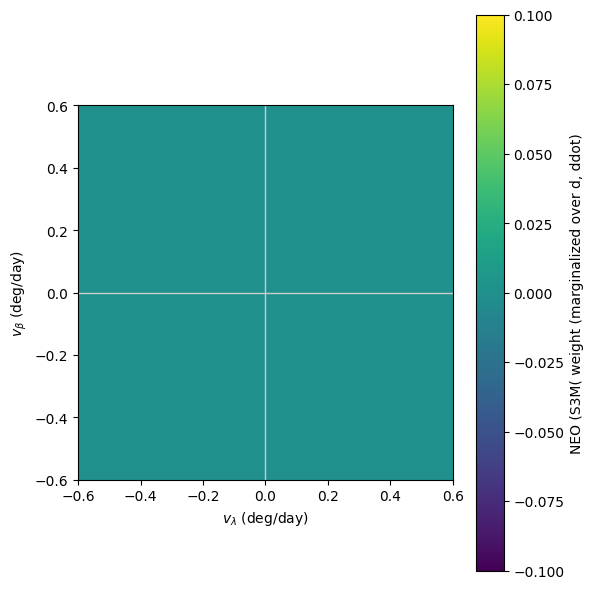

In [132]:
# VERSION WITH FLIPPED DRA VLAMBDA
from matplotlib import cm
plt.figure(figsize=(6.0, 6.0))
 
my_viridis = cm.get_cmap("viridis", 1024).with_extremes(under="white")
im = plt.imshow(K, origin="lower", extent=extent, cmap=my_viridis, aspect="equal")


plt.colorbar(label="NEO (S3M( weight (marginalized over d, ddot)")

plt.axhline(0, color="0.8", lw=1)
plt.axvline(0, color="0.8", lw=1)
plt.xlabel(r"$v_\lambda$ (deg/day)")
plt.ylabel(r"$v_\beta$ (deg/day)")
plt.tight_layout()
plt.show()



### for tno's from S3M

In [138]:
tnos_s3m = tn.define_s3m()

['ST.s3m']
The final df is done.


In [139]:
tnos_s3m,array4D_tn, H_center_tn, a_center_tn, e_center_tn, i_center_tn = tn.s3m_array(tnos_s3m)

In [146]:
obstime_str="2025-09-23T00:00:00"
#ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day = 186.35, -5.0, 46.27, -19.0
ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day = 80.0, 20.0, 0.12, 0.22 
# add mag here
mag = 15.0
# anti-Sun at Sep 23 = equinox so RA = 0, Dec = 0
ra0_deg, dec0_deg = 0.0, 0.0


In [147]:

l_hat, v_hat = nf.compute_unit_vectors(ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day)
obstime, rE, vE, r_obs = nf.get_earth_and_observer(obstime_str) 
tno_score, a, e, i = nf.compute_neomod3_weight(0.2, 3.0, l_hat, v_hat, obstime, rE, vE, r_obs, array4D_tn, H_center_tn, a_center_tn, e_center_tn, i_center_tn)




print("tno_score:", tno_score)
print("a:", a)
print("e:", e)
print("i:", i)

tno_score: 0.0
a: 1.4547289094311036
e: 0.31736085318504975
i: 2.1368116120813023


In [148]:
def comp_sum1():
    
    N_rate = 31           #2 mins 30 sec, for 31 = 4 mins 20 sec so around 50 mins for 101 --> 1 min 40 s for 31
    vlam_min, vlam_max = -0.6, 0.6
    vbet_min, vbet_max = -0.6, 0.6

    vlam_vals  = np.linspace(vlam_min, vlam_max, N_rate)
    vbet_vals = np.linspace(vbet_min, vbet_max, N_rate)
    vlam_deg_day = 0.12
    vbeta_deg_day = 0.22
    

    
    
    K = np.zeros((len(vlam_vals), len(vbet_vals)), dtype=float)
    
    for i,vlam in enumerate(vlam_vals):
        for j,vbet in enumerate(vbet_vals):
            dra, ddec = nf.ecliptic_rates_to_radec_rates(ra0_deg, dec0_deg, vlam, vbet)
            w_int = nf.weight_marginalized_over_d_and_ddot(array4D=array4D_tn, H_center=H_center_tn, a_center=a_center_tn, e_center=e_center_tn, i_center=i_center_tn,
                                                           ra_deg=ra0_deg, dec_deg=dec0_deg, dra_deg_per_day=dra, ddec_deg_per_day=ddec,obstime_str=obstime_str
                                                        )
            

            K[j, i] = w_int
            #print(w_int, dra, ddec)
        #break
    extent = [vlam_vals[0], vlam_vals[-1], vbet_vals[0], vbet_vals[-1]]
    return K, extent

K, extent= comp_sum1()



/tmp/ipykernel_3169730/1045258599.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  my_viridis = cm.get_cmap("viridis", 1024).with_extremes(under="white")


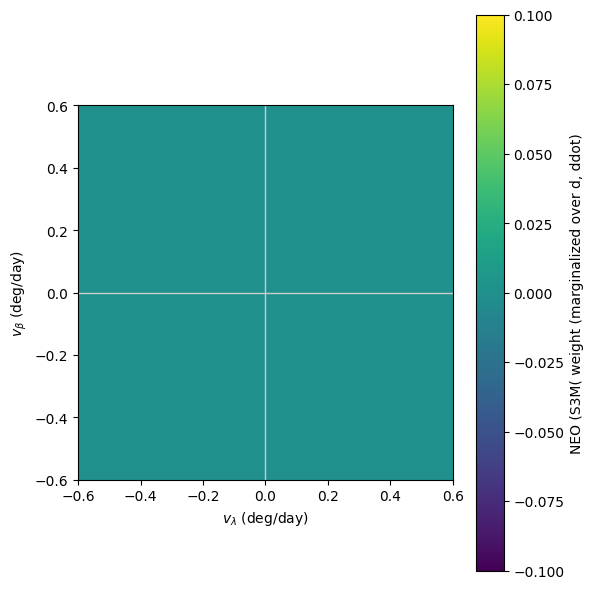

In [149]:
# VERSION WITH FLIPPED DRA VLAMBDA
from matplotlib import cm
plt.figure(figsize=(6.0, 6.0))
 
my_viridis = cm.get_cmap("viridis", 1024).with_extremes(under="white")
im = plt.imshow(K, origin="lower", extent=extent, cmap=my_viridis, aspect="equal")


plt.colorbar(label="NEO (S3M( weight (marginalized over d, ddot)")

plt.axhline(0, color="0.8", lw=1)
plt.axvline(0, color="0.8", lw=1)
plt.xlabel(r"$v_\lambda$ (deg/day)")
plt.ylabel(r"$v_\beta$ (deg/day)")
plt.tight_layout()
plt.show()



In [62]:
# setting value for phi = 0, beta = 0 
phi_deg = 0.0 # on the opposition
beta_deg = 0.0 # on the ecliptic


In [63]:
vE_deg_per_day = 0.986  # earth's orbital speed

def prediction_vlam_vbet(R_au, i_deg, phi_deg, beta_deg=0.0):
    # convert angles to radians
    i = np.deg2rad(i_deg)
    phi = np.deg2rad(phi_deg)
    beta = np.deg2rad(beta_deg)
    
    # from eqn A7 to A8
    theta = phi - np.arcsin(np.sin(phi) / R_au)
    Delta = np.sqrt(R_au**2 + 1.0 - 2.0 * R_au * np.cos(theta))
    
    # heliocentric velocity components 
    v_factor = vE_deg_per_day / np.sqrt(R_au)
    vx = v_factor * np.cos(i) * np.sin(theta)
    vy = v_factor * np.cos(i) * np.cos(theta)
    vz = v_factor * np.sin(i)
    
    # ecliptic rates
    vlam =  (np.sin(phi) * vx + np.cos(phi) * (vy - vE_deg_per_day)) / Delta
    
    vbet = (-np.sin(beta) * np.cos(phi) * vx
            + np.sin(beta) * np.sin(phi) * (vy - vE_deg_per_day)
            + np.cos(beta) * vz) / Delta
    
    return vlam, vbet


In [67]:
i_list = np.arange(-10.0, 15.0, 5.0)  # -10, -5, 0, 5, 10
R_vals = np.linspace(1.5, 6.5, 800)  # AU 

i_lines = []  # [vlam_arr, vbet_arr, i_deg]

for i_deg in i_list:
    vlam_arr = []
    vbet_arr = []
    for R in R_vals:
        vlam, vbet = prediction_vlam_vbet(R, i_deg, phi_deg, beta_deg)
        vlam_arr.append(vlam)
        vbet_arr.append(vbet)
    i_lines.append((np.array(vlam_arr), np.array(vbet_arr), i_deg))


In [68]:
R_list = [2.0, 2.5, 3.0, 3.5]
i_pos = i_center[(i_center >= 0.0) & (i_center <= 60.0)]  # same i-range as neomod3
i_vals_for_R = np.concatenate((-i_pos[::-1], i_pos))
R_lines = []  # [vlam_arr, vbet_arr, R]
for R in R_list:
    vlam_arr = []
    vbet_arr = []
    for i_deg in i_vals_for_R:
        vlam, vbet = prediction_vlam_vbet(R, i_deg, phi_deg, beta_deg)
        vlam_arr.append(vlam)
        vbet_arr.append(vbet)
    R_lines.append((np.array(vlam_arr), np.array(vbet_arr), R))


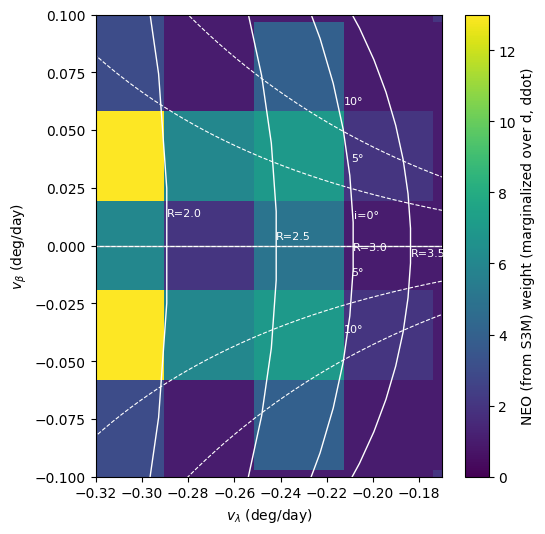

In [47]:
plt.figure(figsize=(6.0, 6.0))
im = plt.imshow(K, origin="lower", extent=extent, cmap="viridis", aspect="equal")
plt.colorbar(label="NEO (from S3M) weight (marginalized over d, ddot)")
plt.axhline(0, color="0.8", lw=1)
plt.axvline(0, color="0.8", lw=1)
plt.xlabel(r"$v_\lambda$ (deg/day)")
plt.ylabel(r"$v_\beta$ (deg/day)")
plt.xlim(-0.32, -0.17)
plt.ylim(-0.1, 0.1)

# solid lines for R
for vlam_arr, vbet_arr, R in R_lines:
    plt.plot(vlam_arr, vbet_arr, color="white", lw=1.0)
    idx = len(vlam_arr) // 2
    plt.text(vlam_arr[idx], vbet_arr[idx] - 0.012,  # a bit below the line
             f"R={R:.1f}", color="white", fontsize=8)

# dashed lines for i
for vlam_arr, vbet_arr, i_deg in i_lines:
    plt.plot(vlam_arr, vbet_arr, color="white", lw=0.8, ls="--")
    idx = len(vlam_arr) // 2
    plt.text(vlam_arr[idx], vbet_arr[idx] + 0.012,
             f"{abs(i_deg):.0f}°" if i_deg != 0 else "i=0°",
             color="white", fontsize=8)